# Introduction to Spinors and the Plane-Dihedral Construction



This notebook introduces the basic concepts of spinors through a two-step geometric idea:



1. Start in 2D with **dihedrals represented by lines** (planar precursor).

2. Promote that construction to 3D as **plane dihedrals** (inclined plane–sphere circle sections).



## What is a Spinor?



A spinor is a mathematical object that represents quantum mechanical spin states. Unlike vectors, spinors have a unique property: they require a $4\pi$ rotation (not $2\pi$) to return to their original state.



A two-component spinor $\psi$ can be written as:



$$\psi = \begin{pmatrix} \psi_\uparrow \\ \psi_\downarrow \end{pmatrix}$$



where $\psi_\uparrow$ and $\psi_\downarrow$ are complex numbers representing the "spin up" and "spin down" amplitudes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Import our spinor visualization package
import sys
sys.path.insert(0, '..')
from spinor_viz import Spinor, plot_spinor_3d, plot_spinor_2d, plot_complex
from spinor_viz.core import pauli, spinor_to_halfangles

%matplotlib inline
plt.rcParams['figure.figsize'] = [8, 8]


## Creating Spinors

Let's create some basic spinor states:

In [2]:
# Spin up state: |↑⟩
spin_up = Spinor.spin_up()
print(f"Spin up: {spin_up}")
print(f"Bloch vector: {spin_up.bloch_vector()}")

# Spin down state: |↓⟩
spin_down = Spinor.spin_down()
print(f"\nSpin down: {spin_down}")
print(f"Bloch vector: {spin_down.bloch_vector()}")


Spin up: Spinor([1.0000+0.0000j, 0.0000+0.0000j])
Bloch vector: [0. 0. 1.]

Spin down: Spinor([0.0000+0.0000j, 1.0000+0.0000j])
Bloch vector: [ 0.  0. -1.]


In [3]:
# Create a spinor from spherical angles
# theta = polar angle, phi = azimuthal angle
s = Spinor.from_angles(theta=np.pi/3, phi=np.pi/4)
print(f"Spinor from angles: {s}")
print(f"Bloch vector: {s.bloch_vector()}")


Spinor from angles: Spinor([0.8001-0.3314j, 0.4619+0.1913j])
Bloch vector: [0.61237244 0.61237244 0.5       ]


## The Pauli Matrices

Spinor rotations are generated by the Pauli matrices $\sigma_x$, $\sigma_y$, $\sigma_z$:

In [4]:
print("σ₀ (Identity):")
print(pauli(0))

print("\nσ₁ (σ_x):")
print(pauli(1))

print("\nσ₂ (σ_y):")
print(pauli(2))

print("\nσ₃ (σ_z):")
print(pauli(3))


σ₀ (Identity):
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

σ₁ (σ_x):
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

σ₂ (σ_y):
[[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]

σ₃ (σ_z):
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]


## Visualizing a Spinor: From Dihedral Lines to Plane Dihedrals



The construction is read in two layers:



- **2D layer (planar precursor):** dihedrals appear as oriented lines that encode half-angle structure.

- **3D layer (full model):** those lines are promoted to **plane-dihedral faces** (inclined plane–sphere circle sections).



In the 3D view, key elements are:



- **Equator circle** (black): Base sphere of radius $|\psi|^2$

- **Upper plane-dihedral face** (blue): Encodes $\psi_\uparrow$

- **Lower plane-dihedral face** (red): Encodes $\psi_\downarrow$

- **Bloch vector** (purple): Spin direction

In [ ]:
# Create and visualize a spinor

s = Spinor.from_angles(theta=np.pi/3, phi=np.pi/4)



fig = plt.figure(figsize=(12, 5))



# 3D view

ax1 = fig.add_subplot(121, projection='3d')

plot_spinor_3d(s, ax=ax1, view_angles=(20, 45))

ax1.set_title('3D Plane-Dihedral View')



# 2D projection

ax2 = fig.add_subplot(122)

plot_spinor_2d(s, ax=ax2)

ax2.set_title('2D Projection')



plt.tight_layout()

plt.show()


## The Half-Angle Parameterization

A spinor can be parameterized by three half-angles:

$$\psi = |\psi| \begin{pmatrix} \cos(\theta/2) e^{-i(\alpha/2 + \phi/2)} \\ \sin(\theta/2) e^{-i(\alpha/2 - \phi/2)} \end{pmatrix}$$

- $\theta/2$: Determines the ratio $|\psi_\downarrow|/|\psi_\uparrow|$
- $\phi/2$: Relative phase (azimuthal angle)
- $\alpha/2$: Overall phase

In [6]:
# Extract half-angles from a spinor
s = Spinor(np.array([1 + 0.5j, 0.5 - 0.3j]))
half_theta, half_alpha, half_phi = s.to_halfangles()

print(f"Spinor: {s}")
print(f"\nHalf-angles:")
print(f"  θ/2 = {np.degrees(half_theta):.2f}°")
print(f"  α/2 = {np.degrees(half_alpha):.2f}°")
print(f"  φ/2 = {np.degrees(half_phi):.2f}°")


Spinor: Spinor([1.0000+0.5000j, 0.5000-0.3000j])

Half-angles:
  θ/2 = 27.54°
  α/2 = 2.20°
  φ/2 = 331.24°


## Visualizing Complex Numbers

Each spinor component is a complex number. The `plot_complex` function visualizes how a complex number can be decomposed:

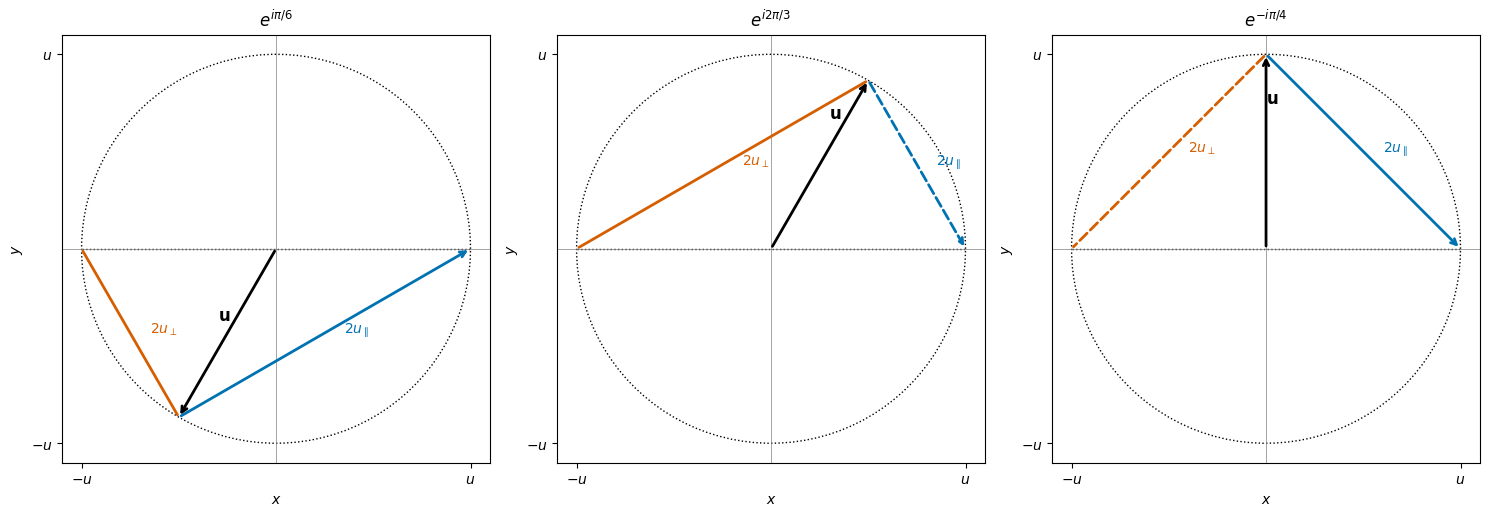

In [7]:
# Visualize different complex numbers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

complex_numbers = [
    (np.exp(1j * np.pi/6), r'$e^{i\pi/6}$'),
    (np.exp(1j * 2*np.pi/3), r'$e^{i 2\pi/3}$'),
    (np.exp(1j * -np.pi/4), r'$e^{-i\pi/4}$')
]

for ax, (c, title) in zip(axes, complex_numbers):
    plot_complex(c, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()


## Gallery: Different Spinor States

Let's visualize a variety of spinor states to build intuition:

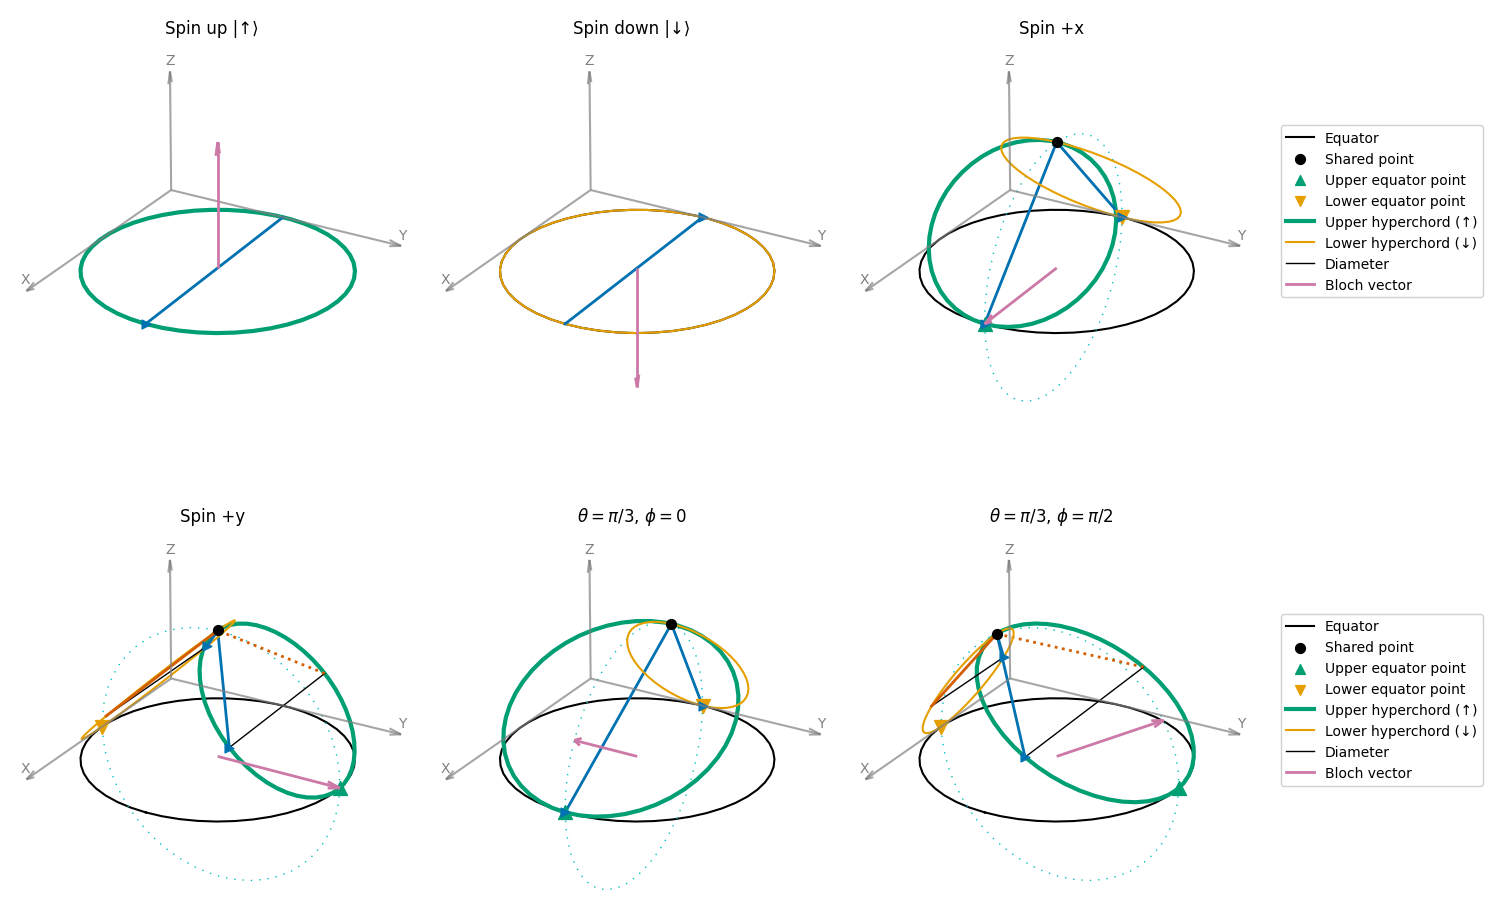

In [8]:
# Create a gallery of different spinors
spinors = [
    ("Spin up |↑⟩", Spinor.spin_up()),
    ("Spin down |↓⟩", Spinor.spin_down()),
    ("Spin +x", Spinor.from_angles(np.pi/2, 0)),
    ("Spin +y", Spinor.from_angles(np.pi/2, np.pi/2)),
    (r"$\theta=\pi/3$, $\phi=0$", Spinor.from_angles(np.pi/3, 0)),
    (r"$\theta=\pi/3$, $\phi=\pi/2$", Spinor.from_angles(np.pi/3, np.pi/2)),
]

fig = plt.figure(figsize=(15, 10))

for i, (name, s) in enumerate(spinors):
    ax = fig.add_subplot(2, 3, i+1, projection='3d')
    plot_spinor_3d(s, ax=ax, view_angles=(25, 30), show_legend=(i+1)%3==0, show_axis_arrows=True)
    ax.set_title(name, y=1)

plt.tight_layout()
plt.show()


## Next Steps

Now that you understand the basics of spinor visualization, continue to:

1. **[02_rotations.ipynb](02_rotations.ipynb)** - Interactive exploration of spinor rotations
2. **[03_animations.ipynb](03_animations.ipynb)** - Animated spinor evolution
3. **[04_quantum_gates.ipynb](04_quantum_gates.ipynb)** - Quantum gates and their spinor representations